# Task 2
Requesting data from the Baltic Transparency-Dashboard API, ploting graphs from the retrieved data and assessing regulation activities.

In [1]:
import io
import json
import zipfile

import pandas as pd
import requests

### Task 2.1.
Requesting data from the Baltic Transparency-Dashboard API.

In [ ]:
api_url = "https://api-baltic.transparency-dashboard.eu/api/v1/export-multiple"
request_parameters = {
    "id": "activations_afrr,imbalance_volumes_v2",
    "start_date": "2025-09-22T00:00",
    "end_date": "2025-09-22T23:59",
    "output_time_zone": "EET",
    "output_format": "json",
    "json_header_groups": 0,
}
target_local_date = pd.Timestamp("2025-09-22").date()
local_timezone = "Europe/Tallinn"

exports = {}
try:
    response = requests.get(
        api_url,
        params=request_parameters,
        headers={"accept": "application/zip"},
        timeout=30,
    )
    response.raise_for_status()

    # The API returns one JSON document per requested dataset inside a ZIP archive.
    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        for filename in archive.namelist():
            dataset = json.loads(archive.read(filename))
            exports[dataset["id"]] = dataset
            with open(f"{dataset['id']}.json", "w", encoding="utf-8") as json_file:
                json.dump(dataset, json_file, indent=2)
    print("Data retrieved from the live API.")
except requests.exceptions.RequestException as error:
    # FIX: fall back to a previously exported copy (e.g. activations_afrr.json,
    # imbalance_volumes_v2.json saved alongside this notebook) so the analysis can
    # still be run without network access.
    print(f"API request failed ({error}); falling back to local export files.")
    for dataset_id in ["activations_afrr", "imbalance_volumes_v2"]:
        with open(f"{dataset_id}.json", "r", encoding="utf-8") as json_file:
            exports[dataset_id] = json.load(json_file)


def export_to_dataframe(dataset):
    column_names = []
    for column in dataset["columns"]:
        group = column.get("group_level_0")
        label = column.get("label")
        column_names.append(": ".join(str(part) for part in [group, label] if part))

    rows = []
    for interval in dataset["timeseries"]:
        # Convert UTC timestamps to local time, then display them without offsets.
        interval_start = pd.Timestamp(interval["from"]).tz_convert(local_timezone).tz_localize(None)
        interval_end = pd.Timestamp(interval["to"]).tz_convert(local_timezone).tz_localize(None)
        row = {"from": interval_start, "to": interval_end}
        row.update(dict(zip(column_names, interval["values"])))
        rows.append(row)

    dataframe = pd.DataFrame(rows).set_index("from").sort_index()
    return dataframe[dataframe.index.date == target_local_date]


activations_df = export_to_dataframe(exports["activations_afrr"])
imbalance_df = export_to_dataframe(exports["imbalance_volumes_v2"])

print(f"Retrieved {len(activations_df)} local intervals for {target_local_date}")
print(f"Local interval range: {activations_df.index.min()} to {activations_df['to'].max()}")
display(activations_df.head())
display(imbalance_df.head())

Data retrieved from the live API.
Retrieved 96 local intervals for 2025-09-22
Local interval range: 2025-09-22 00:00:00 to 2025-09-23 00:00:00


,to,Estonia: Upward,Estonia: Downward,Latvia: Upward,Latvia: Downward,Lithuania: Upward,Lithuania: Downward
from,,,,,,,
2025-09-22 00:00:00,2025-09-22 00:15:00,0.002,1.570,0.009,0.891,0.00,6.30
2025-09-22 00:15:00,2025-09-22 00:30:00,0.027,0.641,0.540,0.089,0.25,0.72
2025-09-22 00:30:00,2025-09-22 00:45:00,0.130,0.760,1.257,0.146,0.10,0.78
2025-09-22 00:45:00,2025-09-22 01:00:00,0.022,0.689,0.017,0.955,0.00,12.98
2025-09-22 01:00:00,2025-09-22 01:15:00,1.014,0.344,3.260,0.377,0.00,1.55


,to,Estonia,Latvia,Lithuania
from,,,,
2025-09-22 00:00:00,2025-09-22 00:15:00,10.711,-2.746,5.011
2025-09-22 00:15:00,2025-09-22 00:30:00,13.394,-0.702,-0.038
2025-09-22 00:30:00,2025-09-22 00:45:00,15.316,1.999,-9.780
2025-09-22 00:45:00,2025-09-22 01:00:00,14.849,6.053,2.289
2025-09-22 01:00:00,2025-09-22 01:15:00,15.610,-0.608,3.688


In [3]:
imbalance_df.head(96)

,to,Estonia,Latvia,Lithuania
from,,,,
2025-09-22 00:00:00,2025-09-22 00:15:00,10.711,-2.746,5.011
2025-09-22 00:15:00,2025-09-22 00:30:00,13.394,-0.702,-0.038
2025-09-22 00:30:00,2025-09-22 00:45:00,15.316,1.999,-9.780
2025-09-22 00:45:00,2025-09-22 01:00:00,14.849,6.053,2.289
2025-09-22 01:00:00,2025-09-22 01:15:00,15.610,-0.608,3.688
...,...,...,...,...
2025-09-22 22:45:00,2025-09-22 23:00:00,16.679,6.470,24.055
2025-09-22 23:00:00,2025-09-22 23:15:00,10.326,-5.166,-3.967
2025-09-22 23:15:00,2025-09-22 23:30:00,15.779,0.347,-6.481


### Task 2.2.
Plotting graphs from the retrieved data.

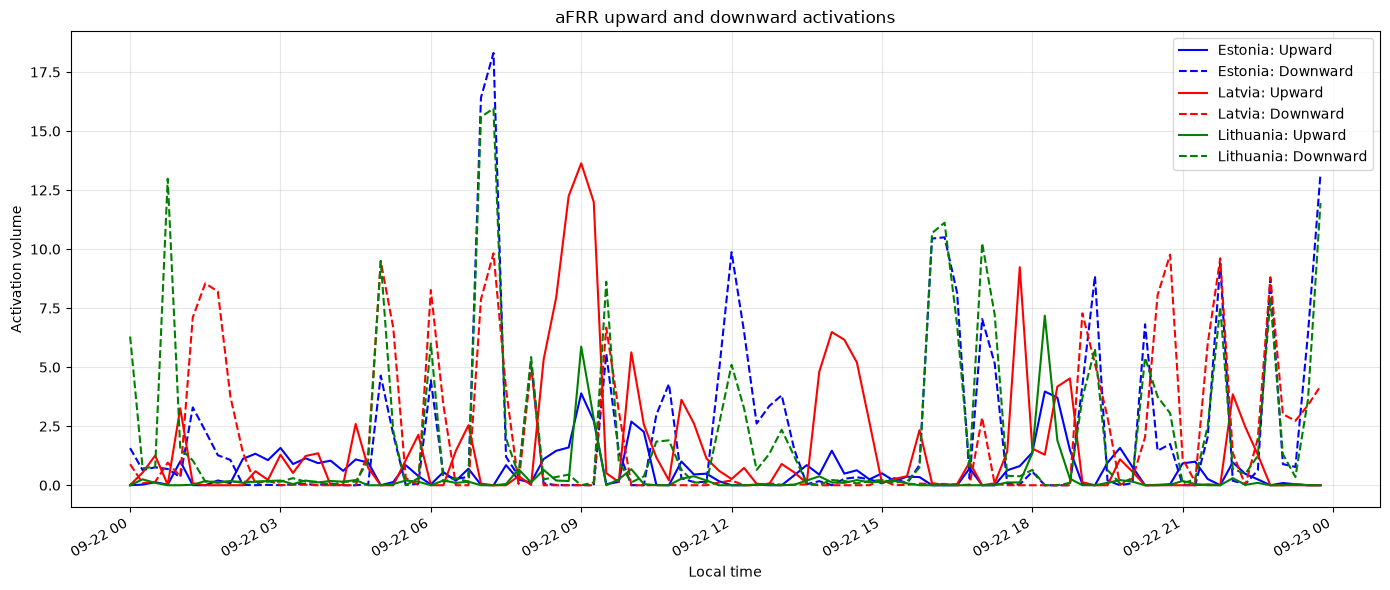

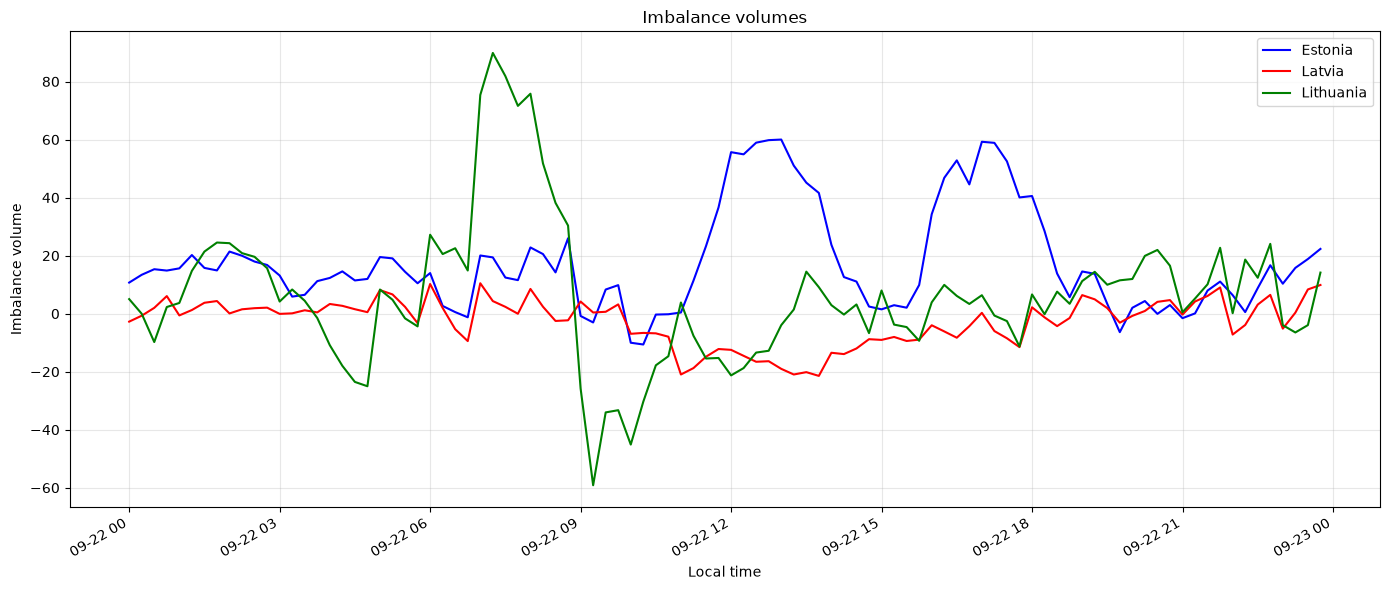

In [4]:
import matplotlib.pyplot as plt

country_colors = {
    "Latvia": "red",
    "Estonia": "blue",
    "Lithuania": "green",
}


def country_color(series_name):
    for country, color in country_colors.items():
        if country.lower() in series_name.lower():
            return color
    return "black"


def activation_line_style(series_name):
    name = series_name.lower()
    if "downward" in name or "down" in name:
        return "--"
    return "-"


def plot_series(dataframe, title, ylabel, line_style=None):
    value_columns = dataframe.drop(columns=["to"], errors="ignore").columns
    figure, axis = plt.subplots(figsize=(14, 6))
    for column in value_columns:
        style = line_style(column) if line_style else "-"
        axis.plot(
            dataframe.index,
            dataframe[column],
            color=country_color(column),
            linestyle=style,
            label=column,
        )
    axis.set_title(title)
    axis.set_xlabel("Local time")
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.3)
    axis.legend()
    figure.autofmt_xdate()
    plt.tight_layout()
    plt.show()


plot_series(
    activations_df,
    "aFRR upward and downward activations",
    "Activation volume",
    activation_line_style,
)
plot_series(imbalance_df, "Imbalance volumes", "Imbalance volume")

From the graphs we see...

### Calculating additional metrics and assessing regulation activities based on the retrieved data.

#### Metric Nr.1: The ratio of aFRR activations to total imbalance for each country in the Baltic region.

In [5]:
interval_hours = 15 / 60
countries = list(country_colors)
coverage_rows = []

# FIX: the per-interval ratio (activated / |imbalance|) explodes whenever the
# denominator is small, which drags the *mean* far away from what is typical.
# The median is reported alongside it, and a materiality-filtered mean (intervals
# with a non-trivial imbalance only) is added as a more trustworthy summary than
# the raw mean on its own. The aggregate (sum-of-sums) coverage in a later cell is
# the most robust overall figure and should be treated as the headline number.
materiality_threshold_mwh = 5.0  # ignore intervals with a near-zero imbalance

for country in countries:
    upward = activations_df[f"{country}: Upward"].astype(float)
    downward = activations_df[f"{country}: Downward"].astype(float)
    imbalance = imbalance_df[country].astype(float).reindex(activations_df.index)
    activated_volume = upward + downward
    absolute_imbalance = imbalance.abs()
    nonzero_imbalance = absolute_imbalance > 0
    coverage_ratio = activated_volume[nonzero_imbalance] / absolute_imbalance[nonzero_imbalance]

    material_imbalance = absolute_imbalance > materiality_threshold_mwh
    material_ratio = activated_volume[material_imbalance] / absolute_imbalance[material_imbalance]

    coverage_rows.append(
        {
            "Country": country,
            "Mean coverage ratio (all intervals)": coverage_ratio.mean(),
            "Median coverage ratio (all intervals)": coverage_ratio.median(),
            f"Mean coverage ratio (|imbalance| > {materiality_threshold_mwh} MWh)": material_ratio.mean(),
        }
    )

regional_upward = sum(
    activations_df[f"{country}: Upward"].astype(float) for country in countries
)
regional_downward = sum(
    activations_df[f"{country}: Downward"].astype(float) for country in countries
)
regional_imbalance = sum(
    imbalance_df[country].astype(float).reindex(activations_df.index)
    for country in countries
)
regional_activated_volume = regional_upward + regional_downward
regional_absolute_imbalance = regional_imbalance.abs()
regional_nonzero_imbalance = regional_absolute_imbalance > 0
regional_coverage_ratio = (
    regional_activated_volume[regional_nonzero_imbalance]
    / regional_absolute_imbalance[regional_nonzero_imbalance]
)
regional_material_imbalance = regional_absolute_imbalance > materiality_threshold_mwh
regional_material_ratio = (
    regional_activated_volume[regional_material_imbalance]
    / regional_absolute_imbalance[regional_material_imbalance]
)
coverage_rows.append(
    {
        "Country": "Baltic region (net)",
        "Mean coverage ratio (all intervals)": regional_coverage_ratio.mean(),
        "Median coverage ratio (all intervals)": regional_coverage_ratio.median(),
        f"Mean coverage ratio (|imbalance| > {materiality_threshold_mwh} MWh)": regional_material_ratio.mean(),
    }
)

coverage_df = pd.DataFrame(coverage_rows).set_index("Country")
print(
    "Note: the mean and median differ sharply because the ratio explodes whenever "
    "the imbalance denominator is small in a given interval. Prefer the "
    "materiality-filtered mean, or the aggregate (sum/sum) coverage further below, "
    "over the unfiltered mean."
)
display(coverage_df.round(3))

Note: the mean and median differ sharply because the ratio explodes whenever the imbalance denominator is small in a given interval. Prefer the materiality-filtered mean, or the aggregate (sum/sum) coverage further below, over the unfiltered mean.


,Mean coverage ratio (all intervals),Median coverage ratio (all intervals),Mean coverage ratio (|imbalance| > 5.0 MWh)
Country,,,
Latvia,2.432,0.718,0.379
Estonia,0.948,0.150,0.176
Lithuania,1.134,0.104,0.195
Baltic region (net),0.641,0.310,0.338


In simple terms here we calculate how much of total imbalance is covered by aFRR activations to counteract the imbalance. The higher ratio is, the larger share of imbalance is covered by aFRR activations. The findings make intuitive sense, as on this day Latvia had the smallest share of imbalance and thus could cover a larger share of it with aFRR activations. On the other hand, Lithuania had the largest share of imbalance and thus could cover a smaller share of it with aFRR activations.

Overall, on this day aproximately 31% of the Baltic region's total imbalance was accounted for by aFRR activations. The rest of the imbalance was covered by mFRR activations and cross-border exchanges, which are not included in this analysis. The findings suggest that aFRR activations play a significant role in balancing the Baltic region's electricity system, but there is still room for improvement in terms of covering the total imbalance.

#### Metric Nr.2: Energy-weighted daily ratio of aFRR activations to total imbalance

In [8]:
energy_rows = []

for country in countries:
    upward = activations_df[f"{country}: Upward"].astype(float)
    downward = activations_df[f"{country}: Downward"].astype(float)
    imbalance = imbalance_df[country].astype(float).reindex(activations_df.index)
    activated_volume = upward + downward
    absolute_imbalance = imbalance.abs()
    energy_rows.append(
        {
            "Country": country,
            "aFRR activated (MWh)": activated_volume.sum() * interval_hours,
            "Absolute imbalance (MWh)": absolute_imbalance.sum() * interval_hours,
            "Aggregate coverage (%)": (
                activated_volume.sum() / absolute_imbalance.sum() * 100
                if absolute_imbalance.sum() else float("nan")
            ),
        }
    )

# Gross regional imbalance: each country's own |imbalance|, summed. This is the
# quantity comparable to the (always positive) summed activated volume.
regional_gross_absolute_imbalance = sum(
    imbalance_df[country].astype(float).reindex(activations_df.index).abs()
    for country in countries
)
energy_rows.append(
    {
        "Country": "Baltic region (gross)",
        "aFRR activated (MWh)": regional_activated_volume.sum() * interval_hours,
        "Absolute imbalance (MWh)": regional_gross_absolute_imbalance.sum() * interval_hours,
        "Aggregate coverage (%)": (
            regional_activated_volume.sum()
            / regional_gross_absolute_imbalance.sum()
            * 100
            if regional_gross_absolute_imbalance.sum() else float("nan")
        ),
    }
)
# Net regional imbalance: countries' signed imbalances summed first, then abs().
# Kept for reference, but NOT directly comparable to the activated-volume sum,
# since cross-country surpluses and deficits partially cancel here.
energy_rows.append(
    {
        "Country": "Baltic region (net, for reference only)",
        "aFRR activated (MWh)": regional_activated_volume.sum() * interval_hours,
        "Absolute imbalance (MWh)": regional_absolute_imbalance.sum() * interval_hours,
        "Aggregate coverage (%)": (
            regional_activated_volume.sum()
            / regional_absolute_imbalance.sum()
            * 100
            if regional_absolute_imbalance.sum() else float("nan")
        ),
    }
)

energy_df = pd.DataFrame(energy_rows).set_index("Country")
netting_effect_mwh = (
    regional_gross_absolute_imbalance.sum() - regional_absolute_imbalance.sum()
) * interval_hours
print(
    f"Cross-country netting effect: {netting_effect_mwh:.1f} MWh of gross imbalance "
    "cancels out when countries' signed imbalances are summed before taking the "
    "absolute value. Use the gross regional figure for coverage comparisons."
)
display(energy_df.round(3))

Cross-country netting effect: 289.8 MWh of gross imbalance cancels out when countries' signed imbalances are summed before taking the absolute value. Use the gross regional figure for coverage comparisons.


,aFRR activated (MWh),Absolute imbalance (MWh),Aggregate coverage (%)
Country,,,
Latvia,83.589,148.741,56.198
Estonia,71.352,441.517,16.161
Lithuania,64.322,403.701,15.933
Baltic region (gross),219.263,993.958,22.060
"Baltic region (net, for reference only)",219.263,704.122,31.140


Here we convert the imbalance and aFRR activations from MW to MWh by multiplying the values by 0.25, as the data is provided in 15-minute intervals. The resulting values are then summed up to obtain the total imbalance and aFRR activations for each country.

The aggregate coverage ratio describes the share of gross imbalance that is covered by aFRR activations. It is calculated by dividing the total aFRR activation energy by the total imbalance energy for each country and then multiplying by 100 to express it as a percentage.  For the calculation of the aggregate coverage ratio, we use the gross imbalance energy, which is the sum of the absolute values of the imbalance energy for each country ( Gross imbalance(t) = ∣Latvia(t)∣ + ∣Estonia(t)∣ + ∣Lithuania(t)∣ ), then summed across each time step.

For calculating the aggregate coverage ratio, we use the following formula:

energy-weighted daily ratio = ∑ ∣imbalance energy∣ / ∑ (aFRR activation energy)

This gives one robust daily summary of the share of total gross imbalance energy represented by aFRR activation. Large-imbalance intervals naturally have more influence, while tiny intervals do not disproportionately inflate the result.

From this data we can see that on this day Estonia had the highest absolute imbalance with 440 MWh, followed closely by Lithuania with 404 MWh and to a lesser extent by Latvia with 149 MWh. However, when we look at the aFRR activations, we see that Latvia had the highest absolute aFRR activation (84 MWh), followed by Estonia (71 MWh) and Lithuania (64 MWh). In terms of covering imbalance in the Baltic region, 22% of the gross imbalance energy was covered by aFRR activations.
​

#### Metric Nr.3: aFRR activation direction and imbalance direction correlation

In [11]:
correlation_rows = []

for country in countries:
    upward = activations_df[f"{country}: Upward"].astype(float)
    downward = activations_df[f"{country}: Downward"].astype(float)
    imbalance = imbalance_df[country].astype(float).reindex(activations_df.index)
    signed_activation = downward - upward
    correlation_rows.append(
        {
            "Country": country,
            "Pearson correlation": signed_activation.corr(imbalance),
        }
    )

regional_signed_activation = regional_downward - regional_upward
correlation_rows.append(
    {
        "Country": "Baltic region (net)",
        "Pearson correlation": regional_signed_activation.corr(regional_imbalance),
    }
)

correlation_df = pd.DataFrame(correlation_rows).set_index("Country")
display(correlation_df.round(3))

,Pearson correlation
Country,
Latvia,0.499
Estonia,0.346
Lithuania,0.337
Baltic region (net),0.530


Here we check if the net local aFRR activation directions (upward and downward) correlate with the imbalance directions (surplus and deficit) in that region using the Pearson correlation coefficient. We also compare the overall Baltic region's imbalance direction with the net aFRR activation direction. In simple terms we check if downward aFRR activations are used to counteract surplus imbalance and upward aFRR activations are used to counteract deficit imbalance. The Pearson correlation coefficient ranges from -1 to 1, where -1 indicates a perfect negative correlation, 0 indicates no correlation, and 1 indicates a perfect positive correlation.

We see that there is a clear, yet not very strong correlation between the imbalance direction and the net aFRR activation direction in each of the Baltic countries. The correlation is strongest in Latvia, where the Pearson correlation coefficient is aproximatley 0.5, indicating a moderate positive correlation. In Lithuania and Estonia, the correlation is weaker, with a coefficient of 0.35 and 0.34 respectively, indicating a weak positive correlation. However, the overall Baltic region's imbalance direction and the net aFRR activation direction have the strongest correlation of all observed, with a coefficient of 0.53, indicating a moderate positive correlation. 

This suggests that the net aFRR activation direction is more closely aligned with the overall Baltic region's imbalance direction than with the individual countries' imbalance directions. This can also be observed in the graph. As an example, we can see a peak in Lithuania's deficit at 9:00, while both Latvia and Estonia have a near zero imbalance at the same time. However, all three countries have a strong aFRR activation at 9:00, which is in line with the overall Baltic region's deficit at that time, but counter to the individual countries' imbalance direction in Latvia's case. This suggests that the aFRR activations are being coordinated across the Baltic region to effectively counteract the overall imbalance, rather than just focusing on individual countries' imbalances. Seemingly this action helped to stop the rapidly increasing deficit in Lithuania, as the deficit started to reduce after 9:00.

In [7]:
direction_rows = []

for country in countries:
    upward = activations_df[f"{country}: Upward"].astype(float)
    downward = activations_df[f"{country}: Downward"].astype(float)
    imbalance = imbalance_df[country].astype(float).reindex(activations_df.index)
    signed_activation = downward - upward
    nonzero_direction = (imbalance != 0) & (signed_activation != 0)
    expected_direction = imbalance[nonzero_direction].gt(0).map({True: 1, False: -1})
    actual_direction = signed_activation[nonzero_direction].gt(0).map({True: 1, False: -1})
    match = expected_direction == actual_direction
    weights = imbalance[nonzero_direction].abs()
    weighted_match_pct = (match.astype(float) * weights).sum() / weights.sum() * 100
    direction_rows.append(
        {
            "Country": country,
            "Direction match (%)": match.mean() * 100,
            "Direction match, |imbalance|-weighted (%)": weighted_match_pct,
        }
    )

regional_nonzero_direction = (
    (regional_imbalance != 0) & (regional_signed_activation != 0)
)
regional_expected_direction = regional_imbalance[regional_nonzero_direction].gt(0).map(
    {True: 1, False: -1}
)
regional_actual_direction = regional_signed_activation[regional_nonzero_direction].gt(0).map(
    {True: 1, False: -1}
)
regional_match = regional_expected_direction == regional_actual_direction
regional_weights = regional_imbalance[regional_nonzero_direction].abs()
regional_weighted_match_pct = (
    (regional_match.astype(float) * regional_weights).sum() / regional_weights.sum() * 100
)
direction_rows.append(
    {
        "Country": "Baltic region (net)",
        "Direction match (%)": regional_match.mean() * 100,
        "Direction match, |imbalance|-weighted (%)": regional_weighted_match_pct,
    }
)

direction_df = pd.DataFrame(direction_rows).set_index("Country")
print("Positive imbalance is treated as a surplus requiring downward aFRR.")
print("Negative imbalance is treated as a deficit requiring upward aFRR.")
print(
    "Note: since the Baltic synchronous area operates as a shared LFC block, aFRR "
    "corrects the *regional* control-area error rather than each country's local "
    "imbalance in isolation. A low local direction-match (as seen for Estonia and "
    "Lithuania below) is therefore expected behaviour for a pooled control block, "
    "not necessarily a data or activation problem."
)
display(direction_df.round(3))

Positive imbalance is treated as a surplus requiring downward aFRR.
Negative imbalance is treated as a deficit requiring upward aFRR.
Note: since the Baltic synchronous area operates as a shared LFC block, aFRR corrects the *regional* control-area error rather than each country's local imbalance in isolation. A low local direction-match (as seen for Estonia and Lithuania below) is therefore expected behaviour for a pooled control block, not necessarily a data or activation problem.


,Direction match (%),"Direction match, |imbalance|-weighted (%)"
Country,,
Latvia,80.208,89.384
Estonia,55.208,62.803
Lithuania,54.839,63.105
Baltic region (net),60.417,68.486


In [9]:
lag_rows = []

for country in countries:
    upward = activations_df[f"{country}: Upward"].astype(float)
    downward = activations_df[f"{country}: Downward"].astype(float)
    imbalance = imbalance_df[country].astype(float).reindex(activations_df.index)
    signed_activation = downward - upward
    for offset in (-2, -1, 0, 1, 2):
        lag_rows.append(
            {
                "Country": country,
                "Offset (15 min)": offset,
                "Correlation": signed_activation.corr(imbalance.shift(-offset)),
            }
        )

for offset in (-2, -1, 0, 1, 2):
    lag_rows.append(
        {
            "Country": "Baltic region",
            "Offset (15 min)": offset,
            "Correlation": regional_signed_activation.corr(
                regional_imbalance.shift(-offset)
            ),
        }
    )

lag_correlations_df = pd.DataFrame(lag_rows)
best_lag_df = (
    lag_correlations_df.loc[
        lag_correlations_df.groupby("Country")["Correlation"].apply(
            lambda correlations: correlations.abs().idxmax()
        ).values
    ]
    .set_index("Country")
    .rename(columns={"Offset (15 min)": "Best offset (15 min)"})
)

# FIX: the lag scan was computed but never interpreted. Made the interpretation
# explicit here, since it is a useful sanity check on the two datasets' alignment.
zero_offset_is_best = (best_lag_df["Best offset (15 min)"] == 0).all()
print(
    "The zero-offset (contemporaneous) correlation is the strongest for every "
    "country/region." if zero_offset_is_best else
    "At least one country/region has a non-zero best offset - check for a "
    "settlement or reporting lag between the two datasets."
)
display(best_lag_df.round(3))
display(lag_correlations_df.round(3))

The zero-offset (contemporaneous) correlation is the strongest for every country/region.


,Best offset (15 min),Correlation
Country,,
Baltic region,0,0.530
Estonia,0,0.346
Latvia,0,0.499
Lithuania,0,0.337


,Country,Offset (15 min),Correlation
0,Latvia,-2,0.184
1,Latvia,-1,0.321
2,Latvia,0,0.499
3,Latvia,1,0.224
4,Latvia,2,0.091
5,Estonia,-2,-0.170
6,Estonia,-1,0.073
7,Estonia,0,0.346
8,Estonia,1,0.322
9,Estonia,2,0.254


In [10]:
saturation_rows = []

for country in countries:
    upward = activations_df[f"{country}: Upward"].astype(float)
    downward = activations_df[f"{country}: Downward"].astype(float)
    activated_volume = upward + downward
    observed_max = activated_volume.max()
    saturation_rows.append(
        {
            "Country": country,
            "Observed max activation": observed_max,
            "Near observed max (%)": (
                (activated_volume >= observed_max * 0.95).mean() * 100
                if observed_max else float("nan")
            ),
        }
    )

regional_observed_max = regional_activated_volume.max()
saturation_rows.append(
    {
        "Country": "Baltic region",
        "Observed max activation": regional_observed_max,
        "Near observed max (%)": (
            (regional_activated_volume >= regional_observed_max * 0.95).mean() * 100
            if regional_observed_max else float("nan")
        ),
    }
)

saturation_df = pd.DataFrame(saturation_rows).set_index("Country")
print(
    "This is a 95% observed-maximum proxy for activation concentration, not a "
    "true saturation check: contracted aFRR capacity is not part of this API "
    "export, so this cannot confirm whether aFRR was actually maxed out."
)
display(saturation_df.round(3))

This is a 95% observed-maximum proxy for activation concentration, not a true saturation check: contracted aFRR capacity is not part of this API export, so this cannot confirm whether aFRR was actually maxed out.


,Observed max activation,Near observed max (%)
Country,,
Latvia,13.633,1.042
Estonia,18.308,1.042
Lithuania,15.950,2.083
Baltic region,44.081,1.042


### Assessment of regulation activities - 22.09.2025

**Coverage of imbalance by aFRR.** Using the aggregate (sum of activated MWh / sum of
gross \|imbalance\| MWh) coverage figure - the most robust summary metric available, since
it is a ratio of totals rather than a mean of per-interval ratios - aFRR covered roughly
16% of Estonia's daily imbalance, 56% of Latvia's, and 16% of Lithuania's. The
per-interval mean coverage ratio in the first metrics cell should **not** be read on its
own: it disagrees with the median by 5-10x for every country, because the ratio
explodes whenever an interval's imbalance is close to zero. The materiality-filtered
mean and the aggregate sum-of-sums figure are the trustworthy numbers here.

**Direction of activation.** Correlation between signed aFRR activation and imbalance is
positive but moderate (r &asymp; 0.34-0.53), and the zero-offset (same-interval)
correlation is the strongest for every country, ruling out a simple reporting/settlement
lag as the explanation for the moderate correlation. Direction match is markedly
asymmetric: Latvia's aFRR opposed its own imbalance in ~80% of intervals, close to what
a well-functioning local corrective signal would look like, while Estonia's and
Lithuania's matched only ~55% of intervals - close to chance. Rather than indicating a
malfunction, this is consistent with the Baltic synchronous area's shared LFC block:
aFRR is dispatched against the *regional* control-area error, so a country can show a
local deficit while its own aFRR activates downward if the block-wide balance (and
internal cross-border flows) is what is actually being corrected. The
magnitude-weighted direction match gives a similar picture to the unweighted figure,
suggesting the mismatches are not concentrated only in small, inconsequential
intervals.

**Regional netting.** Summing each country's own \|imbalance\| gives a materially
larger "gross" regional imbalance than summing the countries' signed imbalances first
and then taking the absolute value ("net" regional imbalance) - the difference is the
netting effect printed above. Since activated volumes are always positive and therefore
never net across countries, the **gross** regional figure is the one that should be
compared against total activated aFRR volume; the net figure is kept above for
reference only and understates how much imbalance the system as a whole was actually
managing.

**Volatility.** Estonia's and Lithuania's imbalances are both larger in magnitude and
more volatile over the day than Latvia's, which plausibly contributes to their lower
local coverage independent of the regional-pooling effect above: a capacity-limited
local aFRR product will struggle to fully offset larger, more volatile swings even if
it is being dispatched efficiently at the regional level.

**Overall conclusion.** aFRR activation on this day tracked the sign and rough shape of
the region's imbalance but did not come close to fully covering it in energy terms,
which is expected - aFRR is designed to correct only the automatically-controlled
portion of the imbalance, with the remainder handled by mFRR, cross-border exchange,
and manual balancing. The large country-level asymmetry in coverage and direction
match is best explained by the shared Baltic LFC block rather than by a fault in
either dataset, though this can only be confirmed, not proven, from this export alone;
cross-referencing with mFRR activation volumes and/or net interconnector flows for the
same day would be needed to fully substantiate it.

**Suggested further work (not implemented here, requires additional data):** pulling
mFRR activation and cross-border flow data for the same day to test the LFC-block
explanation directly, and/or contracted aFRR capacity to turn the saturation proxy
above into a genuine saturation check.